In [341]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
from datetime import datetime


# Test Case 11

In [342]:
quality = pd.read_csv("quality_inspection_cleaned_T18.csv")

In [343]:
severity_map = {
    "Scratch": 3,
    "Dent": 5,
    "Paint Defect": 6,
    "Weld Failure": 9,
    "Engine Failure": 10,
    "Brake Failure": 10,
    "Electrical Fault": 8,
    "Misalignment": 7
}

In [344]:
quality["Severity"] = (
    quality["Defect"]
    .map(severity_map)
    .fillna(5)
)

In [345]:
occurrence = (
    quality.groupby("Defect_Code")
    .size()
    .reset_index(name="Count")
)

In [346]:
max_count = occurrence["Count"].max()

occurrence["Occurrence"] = (
    occurrence["Count"] / max_count * 10
).round().clip(1,10)

In [347]:
quality = quality.merge(
    occurrence[["Defect_Code","Occurrence"]],
    on="Defect_Code",
    how="left"
)

In [348]:
quality["Detection"] = np.where(
    quality["Inspection_Source"].str.upper()=="AUTOMATED",
    2,
    6
)

In [349]:
quality["RPN"] = (
    quality["Severity"] *
    quality["Occurrence"] *
    quality["Detection"]
)

In [350]:
quality["Risk_Level"] = np.where(
    quality["RPN"]>=300,
    "High",
    np.where(
        quality["RPN"]>=100,
        "Medium",
        "Low"
    )
)

In [351]:
pfmea = quality[[
    "Defect_Code",
    "Defect",
    "Severity",
    "Occurrence",
    "Detection",
    "RPN",
    "Risk_Level"
]]

In [352]:
pfmea = pfmea.sort_values(
    by="RPN",
    ascending=False
)

In [353]:
print(pfmea.head(20))

     Defect_Code  Defect  Severity  Occurrence  Detection    RPN Risk_Level
3999        NONE      OK       5.0        10.0          6  300.0       High
3346        NONE      OK       5.0        10.0          6  300.0       High
794         NONE  REJECT       5.0        10.0          6  300.0       High
1760        NONE  REJECT       5.0        10.0          6  300.0       High
798         NONE      OK       5.0        10.0          6  300.0       High
3386        NONE  REJECT       5.0        10.0          6  300.0       High
800         NONE  REJECT       5.0        10.0          6  300.0       High
1758        NONE    NONE       5.0        10.0          6  300.0       High
2618        NONE      OK       5.0        10.0          6  300.0       High
1752        NONE      OK       5.0        10.0          6  300.0       High
810         NONE  REJECT       5.0        10.0          6  300.0       High
817         NONE      OK       5.0        10.0          6  300.0       High
1744        

In [354]:
pfmea.to_csv("PFMEA_Risk_Analysis.csv", index=False)

print("\nPFMEA Risk Analysis Completed Successfully!")


PFMEA Risk Analysis Completed Successfully!


#test case = 12


In [355]:
production = pd.read_csv("production_events.csv")
sensor = pd.read_csv("sensor_readings.csv")

In [356]:
sensor["Energy_kWh"] = pd.to_numeric(sensor["Energy_kWh"], errors="coerce")


In [357]:
data = production.merge(sensor[["Event_ID", "Energy_kWh"]],
                        on="Event_ID",
                        how="left")


In [358]:
vehicle_energy = (
    data.groupby("VIN")["Energy_kWh"]
    .sum()
    .reset_index()
)

In [359]:
vehicle_energy.rename(
    columns={"Energy_kWh": "Total_Energy_kWh"},
    inplace=True
)

In [360]:
vehicle_energy["Energy_per_Vehicle_kWh"] = vehicle_energy["Total_Energy_kWh"]


In [361]:
print(vehicle_energy.head(10))


                 VIN  Total_Energy_kWh  Energy_per_Vehicle_kWh
0  MA1AB100000000001             12.88                   12.88
1  MA1AB100000000002              2.58                    2.58
2  MA1AB100000000003             28.12                   28.12
3  MA1AB100000000004              7.28                    7.28
4  MA1AB100000000005             23.40                   23.40
5  MA1AB100000000006              4.86                    4.86
6  MA1AB100000000007             11.28                   11.28
7  MA1AB100000000008             20.88                   20.88
8  MA1AB100000000009             24.02                   24.02
9  MA1AB100000000010             22.02                   22.02


In [362]:
average_energy = vehicle_energy["Energy_per_Vehicle_kWh"].mean()

print("\nAverage Energy Consumption per Vehicle:")
print(round(average_energy, 2), "kWh")



Average Energy Consumption per Vehicle:
8.58 kWh


In [363]:
vehicle_energy.to_csv(
    "energy_per_vehicle.csv",
    index=False
)

print("\nEnergy Consumption per Vehicle Calculated Successfully!")


Energy Consumption per Vehicle Calculated Successfully!


In [364]:
#test case = 13

In [365]:
quality = pd.read_csv("quality_inspection.csv")


In [366]:
print(quality.columns.tolist())

['Inspection_ID', 'Event_ID', 'VIN', 'Defect_Code', 'Defect', 'Inspection_Source', 'Inspector_ID', 'Rework_Flag', 'Scrap_Reason', 'Result']


In [367]:
quality["Inspection_Result"] = (
    quality["Result"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [368]:
total_inspections = quality["VIN"].nunique()


In [369]:
rework = quality[
    quality["Inspection_Result"] == "REWORK"
]["VIN"].nunique()

In [370]:
reinspection = quality[
    quality["Inspection_Result"] == "RE-INSPECTION"
]["VIN"].nunique()


In [371]:
reinspection_rate = (reinspection / total_inspections) * 100


In [372]:
summary = pd.DataFrame({
    "Total_Vehicles_Inspected": [total_inspections],
    "Vehicles_Reworked": [rework],
    "Vehicles_Reinspected": [reinspection],
    "Reinspection_Rate_%": [round(reinspection_rate, 2)]
})

In [373]:
summary.to_csv(
    "rework_analytics.csv",
    index=False
)

print("\nRework Loop Analytics Completed Successfully!")


Rework Loop Analytics Completed Successfully!


#test case = 14

In [374]:
supplier = pd.read_csv("supplier_master.csv")


In [375]:
supplier_metrics = supplier[[
    "Supplier_Code",
    "Supplier_Name",
    "Quality_Rating",
    "PPM_Defects",
    "On_Time_Delivery_%"
]]

print(supplier_metrics.head(10))

  Supplier_Code     Supplier_Name  Quality_Rating  PPM_Defects  \
0       SUP-001   Auto Supplier 1             3.8           51   
1       SUP-002   Auto Supplier 2             3.7          257   
2       SUP-003   Auto Supplier 3             3.2          499   
3       SUP-004   Auto Supplier 4             4.7          470   
4       SUP-005   Auto Supplier 5             3.1          417   
5       SUP-006   Auto Supplier 6             3.3           48   
6       SUP-007   Auto Supplier 7             3.8          482   
7       SUP-008   Auto Supplier 8             3.3          192   
8       SUP-009   Auto Supplier 9             4.9          220   
9       SUP-010  Auto Supplier 10             3.0          172   

   On_Time_Delivery_%  
0                  93  
1                  87  
2                  88  
3                  86  
4                  93  
5                  98  
6                  86  
7                  93  
8                  88  
9                  95  


In [376]:
avg_ppm = supplier["PPM_Defects"].mean()


In [377]:
avg_delivery = supplier["On_Time_Delivery_%"].mean()

print("\nAverage Supplier PPM :", round(avg_ppm,2))
print("Average On-Time Delivery :", round(avg_delivery,2), "%")


Average Supplier PPM : 265.76
Average On-Time Delivery : 92.74 %


In [378]:
best_supplier = supplier.sort_values(
    by=["Quality_Rating","On_Time_Delivery_%"],
    ascending=False
).head(1)

print("\nBest Performing Supplier")
print(best_supplier[[
    "Supplier_Code",
    "Supplier_Name",
    "Quality_Rating",
    "PPM_Defects",
    "On_Time_Delivery_%"
]])


Best Performing Supplier
    Supplier_Code      Supplier_Name  Quality_Rating  PPM_Defects  \
166       SUP-167  Auto Supplier 167             5.0           92   

     On_Time_Delivery_%  
166                  97  


In [379]:
supplier_metrics.to_csv(
    "supplier_performance_metrics.csv",
    index=False
)

print("\nSupplier Performance Metrics Calculated Successfully!")


Supplier Performance Metrics Calculated Successfully!


In [380]:
#test case = 15

In [381]:
tool = pd.read_csv("tool_master.csv")


In [382]:
tool["Calibration_Date"] = pd.to_datetime(
    tool["Calibration_Date"],
    errors="coerce"
)

tool["Next_Due_Date"] = pd.to_datetime(
    tool["Next_Due_Date"],
    errors="coerce"
)

In [383]:
today = pd.Timestamp.today().normalize()


In [384]:
tool["Calibration_Status"] = tool["Next_Due_Date"].apply(
    lambda x: "Overdue" if pd.notna(x) and x < today else "Valid"
)

In [385]:
total_tools = len(tool)


In [386]:
valid_tools = (tool["Calibration_Status"] == "Valid").sum()


In [387]:
overdue_tools = (tool["Calibration_Status"] == "Overdue").sum()


In [388]:
adherence = (valid_tools / total_tools) * 100


In [389]:
kpi = pd.DataFrame({
    "Total_Tools": [total_tools],
    "Valid_Tools": [valid_tools],
    "Overdue_Tools": [overdue_tools],
    "Calibration_Adherence_%": [round(adherence, 2)]
})

print(kpi)

   Total_Tools  Valid_Tools  Overdue_Tools  Calibration_Adherence_%
0          100           21             79                     21.0


In [390]:
kpi.to_csv("tool_calibration_kpi.csv", index=False)

print("\nTool Calibration KPI Generated Successfully!")


Tool Calibration KPI Generated Successfully!


In [391]:
# test case = 16

In [392]:
production = pd.read_csv("production_events_cleaned_T21_oee.csv")


In [393]:
production["Timestamp"] = pd.to_datetime(
    production["Timestamp"],
    errors="coerce"
)

In [394]:
production["Hour"] = production["Timestamp"].dt.hour


In [395]:
production["Shift"] = np.select(
    [
        (production["Hour"] >= 6) & (production["Hour"] < 14),
        (production["Hour"] >= 14) & (production["Hour"] < 22)
    ],
    [
        "Morning",
        "Afternoon"
    ],
    default="Night"
)

In [396]:
shift_performance = (
    production.groupby("Shift")
    .size()
    .reset_index(name="Vehicles_Produced")
)

In [397]:
total = shift_performance["Vehicles_Produced"].sum()

shift_performance["Production_%"] = (
    shift_performance["Vehicles_Produced"] / total * 100
).round(2)


In [398]:
print(shift_performance)


       Shift  Vehicles_Produced  Production_%
0  Afternoon               1544         30.88
1    Morning               1920         38.40
2      Night               1536         30.72


In [399]:
shift_performance.to_csv(
    "shift_performance.csv",
    index=False
)

print("\nShift Performance Comparison Completed Successfully!")


Shift Performance Comparison Completed Successfully!


In [400]:
#test case - 17

In [401]:
warranty = pd.read_csv("warranty_claims.csv")


In [402]:
warranty.columns = [
    "Claim_ID",
    "VIN",
    "Claim_Date",
    "Failure_Code",
    "Failure_Description",
    "Repair_Cost",
    "Dealer",
    "Repair_Action",
    "Claim_Status",
    "Severity"
]

In [403]:
warranty["Claim_Date"] = pd.to_datetime(warranty["Claim_Date"], errors="coerce")
warranty["Repair_Cost"] = pd.to_numeric(warranty["Repair_Cost"], errors="coerce")

In [404]:
part_summary = warranty.groupby("Failure_Description").agg(
    Total_Claims=("Claim_ID", "count"),
    Total_Repair_Cost=("Repair_Cost", "sum"),
    Average_Repair_Cost=("Repair_Cost", "mean")
).reset_index()

In [405]:
threshold = 10   # Change if required
part_summary["Warning_Status"] = part_summary["Total_Claims"].apply(
    lambda x: "Early Warning" if x >= threshold else "Normal"
)

In [406]:
part_summary = part_summary.sort_values(
    by="Total_Claims",
    ascending=False
)

In [407]:
print(part_summary.head(20))


          Failure_Description  Total_Claims  Total_Repair_Cost  \
0          ABS Module Failure             1               1380   
74       Rear Door Window Jam             1                280   
72      Rear Defogger Failure             1                410   
71        Rear Camera Failure             1                560   
70           Rear Brake Noise             1                410   
69            Rear Axle Noise             1                890   
68              Radiator Leak             1                980   
67         Radiator Fan Noise             1                520   
66       Radiator Fan Failure             1                620   
65       Power Window Failure             1                270   
64     Power Steering Failure             1               1560   
63       Power Mirror Failure             1                260   
62     Parking Sensor Failure             1                390   
61      Oxygen Sensor Failure             1                450   
60        

In [408]:
part_summary.to_csv(
    "warranty_early_warning.csv",
    index=False
)

print("\nWarranty Early Warning Analysis Completed Successfully!")


Warranty Early Warning Analysis Completed Successfully!


In [409]:
#test case = 18

In [410]:
production = pd.read_csv("production_events_cleaned_T21_oee.csv")
sensor = pd.read_csv("sensor_readings.csv")

In [411]:
digital_twin = production.merge(
    sensor,
    on="Event_ID",
    how="left"
)

In [412]:
numeric_cols = [
    "Torque",
    "Temperature",
    "Pressure",
    "Vibration_mm_s",
    "Energy_kWh"
]

for col in numeric_cols:
    digital_twin[col] = pd.to_numeric(
        digital_twin[col],
        errors="coerce"
    )

In [413]:
digital_twin["High_Torque"] = digital_twin["Torque"] > 50
digital_twin["High_Temperature"] = digital_twin["Temperature"] > 80
digital_twin["High_Pressure"] = digital_twin["Pressure"] > 150
digital_twin["High_Vibration"] = digital_twin["Vibration_mm_s"] > 5
digital_twin["High_Energy"] = digital_twin["Energy_kWh"] > 10

In [414]:
digital_twin["Risk_Score"] = (
    digital_twin["High_Torque"].astype(int) +
    digital_twin["High_Temperature"].astype(int) +
    digital_twin["High_Pressure"].astype(int) +
    digital_twin["High_Vibration"].astype(int) +
    digital_twin["High_Energy"].astype(int)
)

In [415]:
def risk_level(score):
    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

digital_twin["Quality_Risk"] = digital_twin["Risk_Score"].apply(risk_level)

In [416]:
print(digital_twin[
    [
        "Event_ID",
        "VIN",
        "Torque",
        "Temperature",
        "Pressure",
        "Vibration_mm_s",
        "Energy_kWh",
        "Risk_Score",
        "Quality_Risk"
    ]
].head(20))

   Event_ID                VIN  Torque  Temperature  Pressure  Vibration_mm_s  \
0     M8000  MA1A**********000     NaN          NaN       NaN            1.79   
1    M11000  MA1A**********000     NaN          NaN       NaN            8.19   
2    M11000  MA1A**********000     NaN          NaN       NaN            5.24   
3     M9000  MA1A**********000     NaN          NaN       NaN            1.34   
4    M10000  MA1A**********000     NaN          NaN       NaN            5.45   
5    M10000  MA1A**********000     NaN          NaN       NaN            7.11   
6    M10000  MA1A**********000     NaN          NaN       NaN            4.66   
7     M9001  MA1A**********001     NaN          NaN       NaN            8.41   
8     M9001  MA1A**********001     NaN          NaN       NaN            6.27   
9     M9001  MA1A**********001     NaN          NaN       NaN            5.43   
10    M8001  MA1A**********001     NaN          NaN       NaN            2.13   
11    M8001  MA1A**********0

In [417]:
digital_twin.to_csv(
    "digital_twin_features.csv",
    index=False
)

print("\nDigital Twin Feature Set Created Successfully!")


Digital Twin Feature Set Created Successfully!


In [418]:
#test case = 19


In [419]:
production = pd.read_csv("production_events_cleaned_T21_oee.csv")


In [420]:
production["Timestamp"] = pd.to_datetime(
    production["Timestamp"],
    errors="coerce"
)

In [421]:
production = production.sort_values(
    by=["Line", "Station", "Timestamp"]
)

In [422]:
production["Cycle_Time_sec"] = (
    production.groupby(["Line", "Station"])["Timestamp"]
    .diff()
    .dt.total_seconds()
)

In [423]:
production = production.dropna(subset=["Cycle_Time_sec"])


In [424]:
available_time = 480


In [425]:
daily_demand = 240


In [426]:
takt_time = available_time / daily_demand


In [427]:
production["Cycle_Time_min"] = (
    production["Cycle_Time_sec"] / 60
)

In [428]:
production["Takt_Status"] = production["Cycle_Time_min"].apply(
    lambda x: "Within Takt" if x <= takt_time else "Above Takt"
)

In [429]:
line_balance = production.groupby(["Line", "Station"]).agg(
    Average_Cycle_Time=("Cycle_Time_min", "mean"),
    Maximum_Cycle_Time=("Cycle_Time_min", "max"),
    Vehicles_Processed=("Event_ID", "count")
).reset_index()

In [430]:
line_balance["Balance_Efficiency_%"] = (
    takt_time / line_balance["Average_Cycle_Time"] * 100
).round(2)

print(line_balance)

print("\nTakt Time:", takt_time, "minutes")

       Line Station  Average_Cycle_Time  Maximum_Cycle_Time  \
0      GA-1  STN-01           34.383333               155.0   
1      GA-1  STN-02           41.780822               298.0   
2      GA-1  STN-03           15.423940                85.0   
3      GA-1  STN-04           33.000000               170.0   
4      GA-1  STN-05           18.145773               117.0   
5      GA-2  STN-01           33.912568               226.0   
6      GA-2  STN-02           34.115385               178.0   
7      GA-2  STN-03           17.418994                85.0   
8      GA-2  STN-04           30.450495               141.0   
9      GA-2  STN-05           17.814286                86.0   
10  PAINT-1  STN-01           41.918919               232.0   
11  PAINT-1  STN-02           36.976190               200.0   
12  PAINT-1  STN-03           18.137427               135.0   
13  PAINT-1  STN-04           36.058140               190.0   
14  PAINT-1  STN-05           18.865854               1

In [431]:
line_balance.to_csv(
    "line_balance_metrics.csv",
    index=False
)

print("\nLine Balance Metrics Generated Successfully!")


Line Balance Metrics Generated Successfully!


In [432]:
#test case =20

In [433]:
plan = pd.read_csv("production_plan_vs_Actual_Dashboard.csv")
production = pd.read_csv("production_events.csv")

In [434]:
print(plan.columns.tolist())
print(plan.head())

['Line', 'Planned_Production', 'Actual_Production', 'Variance', 'Variance (%)', 'Achievement (%)']
      Line  Planned_Production  Actual_Production  Variance  Variance (%)  \
0     GA-1              694301             648427    -45874         -6.61   
1     GA-2              705505             659857    -45648         -6.47   
2  PAINT-1              643838             601630    -42208         -6.56   
3   TRIM-1              713784             666831    -46953         -6.58   

   Achievement (%)  
0            93.39  
1            93.53  
2            93.44  
3            93.42  


In [435]:
# Convert numeric columns
plan["Planned_Production"] = pd.to_numeric(plan["Planned_Production"], errors="coerce")
plan["Actual_Production"] = pd.to_numeric(plan["Actual_Production"], errors="coerce")

In [436]:
plan["Variance"] = plan["Actual_Production"] - plan["Planned_Production"]


In [437]:
plan["Variance (%)"] = (
    plan["Variance"] / plan["Planned_Production"] * 100
).round(2)

In [438]:
plan["Achievement (%)"] = (
    plan["Actual_Production"] / plan["Planned_Production"] * 100
).round(2)

In [439]:
plan["Status"] = plan["Variance"].apply(
    lambda x: "Target Achieved" if x >= 0 else "Below Target"
)

In [440]:
print(plan)


      Line  Planned_Production  Actual_Production  Variance  Variance (%)  \
0     GA-1              694301             648427    -45874         -6.61   
1     GA-2              705505             659857    -45648         -6.47   
2  PAINT-1              643838             601630    -42208         -6.56   
3   TRIM-1              713784             666831    -46953         -6.58   

   Achievement (%)        Status  
0            93.39  Below Target  
1            93.53  Below Target  
2            93.44  Below Target  
3            93.42  Below Target  


In [441]:
plan.to_csv("production_variance_dashboard.csv", index=False)


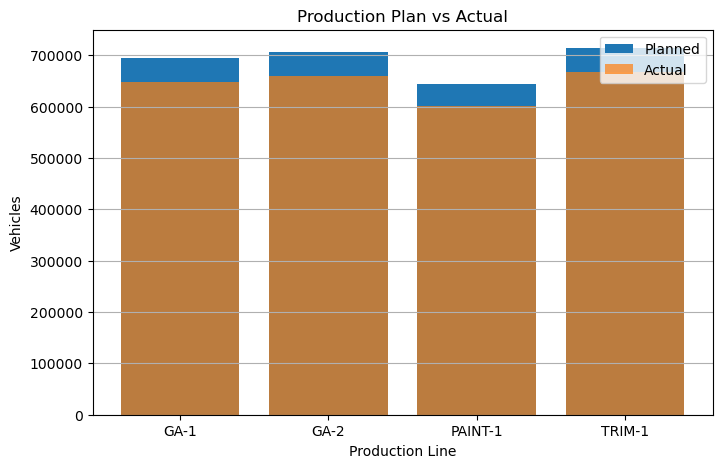


Dashboard Generated Successfully!


In [442]:
plt.figure(figsize=(8,5))

plt.bar(plan["Line"], plan["Planned_Production"], label="Planned")
plt.bar(plan["Line"], plan["Actual_Production"], alpha=0.7, label="Actual")

plt.title("Production Plan vs Actual")
plt.xlabel("Production Line")
plt.ylabel("Vehicles")

plt.legend()

plt.grid(axis="y")

plt.show()

print("\nDashboard Generated Successfully!")